# Setup and Imports

In [176]:
# necessary packages for neural networks in PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

# for gradient descents
import torch.optim as optim

# image processing library
from PIL import Image
import torchvision.transforms as transforms

# train or load pretrained models
from torchvision.models import vgg19, VGG19_Weights

import matplotlib.pyplot as plt

In [177]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

# Loading the Images

In [178]:
imsize = 512 if torch.cuda.is_available() else 128                              # use small size if no gpu

loader = transforms.Compose([
    transforms.Resize((imsize,imsize)),
    transforms.ToTensor()                                                       # Transform it to tensor
])

def image_loader(image_name):
    image = Image.open(image_name).convert("RGB")
    image = loader(image).unsqueeze(0)                                          # Add dimension to fit network's input dims: (1,3,H,W)
    return image.to(device, torch.float)

In [179]:
style_img = image_loader("/content/neural_style_transfer/style_images/pencil_style_img1.jpg")
content_img = image_loader("/content/neural_style_transfer/content_images/content_img1.png")

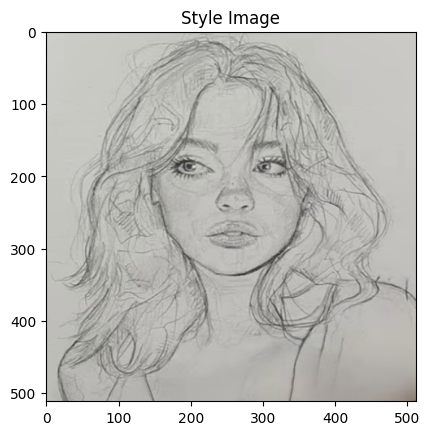

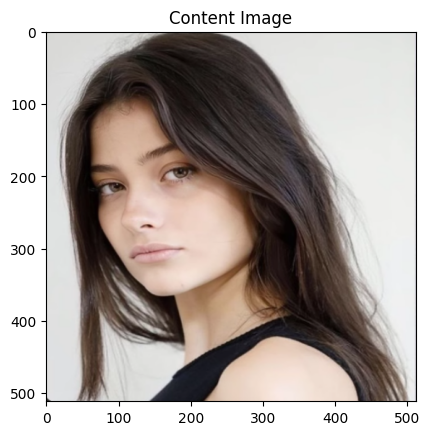

In [180]:
unloader = transforms.ToPILImage()                                              # reconvert to PIL image
plt.ion()

def imshow(tensor,title=None):
    image = tensor.cpu().clone()                                                # clone the tensor to not make changes on it directly
    image = image.squeeze(0)                                                    # remove the dimension added to the tensor earlier -> (3,H,W)
    image = unloader(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)                                                            # slight pause so plots are updated

plt.figure()
imshow(style_img, title='Style Image')

plt.figure()
imshow(content_img, title='Content Image')

# Loss Functions

### Content Loss

In [181]:
class ContentLoss(nn.Module):
  def __init__(self, target):
    super(ContentLoss, self).__init__()
    self.target = target.detach()

  def forward(self, input):
    self.loss = F.mse_loss(input, self.target)
    return input

### Style Loss

In [182]:
def gram_matrix(input):
  a,b,c,d = input.size()                                                        # a: batch size, b: number of feature maps, (c,d): dimensions of feature map

  features = input.view(a * b, c * d) # Reshape to a 2D matrix

  G = torch.mm(features, features.t())                                          # compute the gram product

  return G.div(a*b*c*d)                                                         # Normalize values of the gram matrix

class StyleLoss(nn.Module):
  def __init__(self,target_feature):
    super().__init__()
    self.target = gram_matrix(target_feature).detach() # Corrected typo: detatch() -> detach()

  def forward(self,input):
    G = gram_matrix(input)
    self.loss = F.mse_loss(G, self.target)
    return input

# The Model

In [183]:
cnn = vgg19(weights=VGG19_Weights.DEFAULT).features.eval()

### Normalization Module

In [184]:
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406])                    # VGG's training images have each of R,G,B normalized by mean [0.485, 0.456, 0.406]
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225])                     # VGG's training images have each of R,G,B normalized by std [0.229, 0.224, 0.225]

class Normalization(nn.Module):                                                 # custom pytorch layer that normalizes images - to transform numbers into the format VGG19 expects
  def __init__(self, mean, std):
    super().__init__()
    self.mean = torch.tensor(mean).view(-1,1,1)                                 # converting mean into a tensor, then reshaping it from shape=[3] to [3,1,1]; 3 channels of 1w 1h
    self.std =torch.tensor(std).view(-1,1,1)                                    # converting std into a tensor...

  def forward(self, img):
    return (img - self.mean) / self.std                                         # Normalize img (pixel by pixel)

### Sequential Module

In [185]:
# Earlier Conv. Layers capture lower-level features (edges, colors, textures...) while deeper conv. layers capture more abstract features (structure, layout, larger shapes...)
content_layers_default = ['conv_4']
style_layers_default = ['conv_1', 'conv_2', 'conv_3', 'conv_4','conv_5']

def get_style_model_and_losses (cnn,
                                cnn_normalization_mean,
                                cnn_normalization_std,
                                style_img,
                                content_img,
                                content_layers =content_layers_default,
                                style_layers = style_layers_default):

                                # Normalization Module
                                normalization = Normalization(cnn_normalization_mean, cnn_normalization_std)

                                # Lists for content & style losses
                                content_losses = []
                                style_losses = []

                                # NN is sequential, so we add modules to be activated sequentially
                                model = nn.Sequential(normalization)

                                i=0
                                # Loop through the VGG Layers
                                for layer in cnn.children():
                                  if isinstance(layer, nn.Conv2d):
                                    i+=1
                                    name = 'conv_{}'.format(i)

                                  elif isinstance(layer, nn.ReLU):
                                    name = 'relu_{}'.format(i)
                                    layer = nn.ReLU(inplace=False)              # some ReLU layers modify tensors in-place (directly) affecting content loss & style loss; set False

                                  elif isinstance(layer, nn.MaxPool2d):
                                    name = 'pool_{}'.format(i)

                                  elif isinstance(layer, nn.BatchNorm2d):
                                    name = 'batchNorm_{}'.format(i)

                                  else:
                                    raise RuntimeError('Unrecognized layer: {}'.format(layer.__class__.__name__))

                                  model.add_module(name, layer)

                                  # When we reach the selected content layer, save the content image features as the target.
                                  if name in content_layers:
                                    target = model(content_img).detach()
                                    content_loss = ContentLoss(target)
                                    model.add_module("content_loss_{}".format(i), content_loss)
                                    content_losses.append(content_loss)

                                  # When we reach each selected style layer, save the style image’s Gram matrix as the target style.
                                  if name in style_layers:
                                    target_feature = model(style_img).detach()
                                    style_loss = StyleLoss(target_feature)
                                    model.add_module("style_loss_{}".format(i), style_loss)
                                    style_losses.append(style_loss)

                                # After the last content/style loss, extra VGG layers are useless so we trim them
                                for i in range(len(model) -1, -1, -1):
                                  if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
                                    break

                                model = model[:(i+1)]
                                return model, style_losses, content_losses



### Optimizer (Gradient Descent)

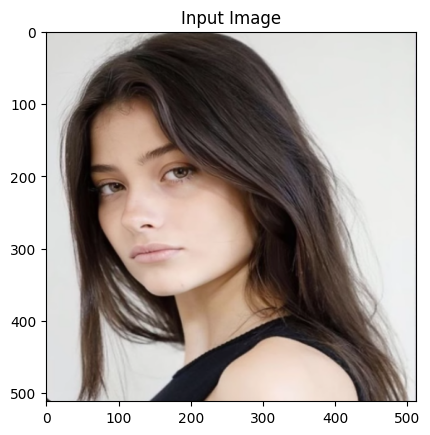

In [186]:
# For content loss, we want the content_img to stay unchanged by the optimizer, so we clone it
input_img = content_img.clone()

plt.figure()
imshow(input_img, title='Input Image')

In [187]:
# we will use L-BFGS algorithm to run our gradient descent (Unlike training a network, we want to train the input image to minimize content/style losses)
def get_input_optimizer(input_img):
  optimizer= optim.LBFGS([input_img]) # input_img is passed as a tensor
  return optimizer

In [188]:
def run_style_transfer(cnn,
                       normalization_mean,
                       normalization_std,
                       content_img,
                       style_img,
                       input_img,
                       num_steps=600,
                       style_weight=10000000,
                       content_weight=5):

    print('Building the style transfer model..')

    model, style_losses, content_losses = get_style_model_and_losses(
        cnn,
        normalization_mean,
        normalization_std,
        style_img,
        content_img
    )

    print("Content loss layers:", len(content_losses))
    print("Style loss layers:", len(style_losses))

    input_img.requires_grad_(True)
    model.eval()
    model.requires_grad_(False)

    optimizer = get_input_optimizer(input_img)

    print('Optimizing..')

    run = [0]

    while run[0] <= num_steps:

        # Optimizer requires a closure function that reevaluates the module and returns loss
        def closure():
            # Keep image pixel values between 0 and 1
            with torch.no_grad():
                input_img.clamp_(0, 1)

            # Clear old gradients
            optimizer.zero_grad()

            # Send generated (input) image through the VGG model
            model(input_img)

            # Calculate total style loss
            style_score = 0
            for sl in style_losses:
                style_score += sl.loss

            # Calculate total content loss
            content_score = 0
            for cl in content_losses:
                content_score += cl.loss

            # Apply weights
            style_score *= style_weight
            content_score *= content_weight

            # Total loss
            loss = style_score + content_score

            # Backpropagation (how should each pixel change to reduce the loss)
            loss.backward()

            # Print progress and losses every 50 runs
            run[0] += 1

            if run[0] % 50 == 0:
                print("run {}:".format(run[0]))
                print("Style Loss: {:.4f} Content Loss: {:.4f}".format(
                    style_score.item(),
                    content_score.item()
                ))
                print()

            return loss

        optimizer.step(closure) # update the image

    # Final clamp after optimization (to keep between 0 and 1)
    with torch.no_grad():
        input_img.clamp_(0, 1)

    return input_img

# Run

Building the style transfer model..
Content loss layers: 1
Style loss layers: 5
Optimizing..
run 50:
Style Loss: 374.1267 Content Loss: 33.2045

run 100:
Style Loss: 163.1271 Content Loss: 36.8357

run 150:
Style Loss: 107.5851 Content Loss: 34.9306

run 200:
Style Loss: 83.7916 Content Loss: 30.6516

run 250:
Style Loss: 51.4037 Content Loss: 28.6511

run 300:
Style Loss: 27.0323 Content Loss: 26.8252

run 350:
Style Loss: 16.3800 Content Loss: 24.5026

run 400:
Style Loss: 9.3803 Content Loss: 22.3504

run 450:
Style Loss: 5.2589 Content Loss: 20.8438

run 500:
Style Loss: 3.1756 Content Loss: 19.7313

run 550:
Style Loss: 2.1446 Content Loss: 18.8569

run 600:
Style Loss: 1.6146 Content Loss: 18.1849



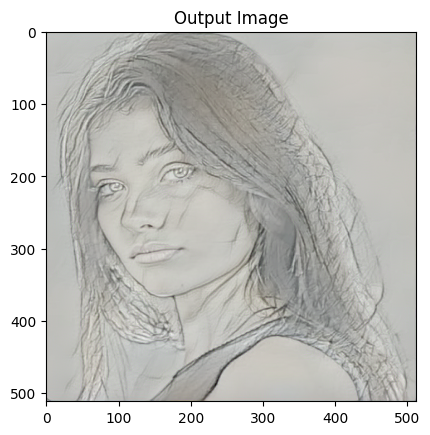

In [189]:
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std, content_img, style_img, input_img)

plt.figure()
imshow(output, title='Output Image')

plt.ioff()
plt.show()
